In [29]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("Distributed Shared Variables")
    .master("spark://4619b568af8b:7077")
    .config("spark.pyspark.python", "/usr/bin/python3")
    .config("spark.cores.max",16)
    .config("spark.executor.cores",4)
    .config("spark.executor.memory","512M")
    .getOrCreate()
)

spark

In [30]:
# Read EMP CSV data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id integer"
emp = spark.read.format("csv").schema(_schema).option("header", True).load("/data/csv/employee_records.csv")

## Broadcast Variables

Consider a case where we want to populate `department_name` according to the `department_id`. What options do we have?

**Option 1 — Join with a Department DataFrame:**
Create a department DataFrame and join it with the employee DataFrame to populate department names.
The problem: this invokes a **shuffle** (data exchange across executors), which is expensive.

**Option 2 — Pass a lookup variable via a UDF/map:**
Create a lookup dictionary and pass it with a UDF or map operation.
The problem: the variable gets **serialized into the task closure** and is sent **once per task** to every executor. Since there can be many tasks (one per partition), this results in redundant copies being shipped across the network, creating a **bottleneck**.

**Option 3 (Solution) — Broadcast Variable:**
When we create a broadcast variable, Spark sends it **once to each worker node** using an efficient peer-to-peer protocol (like BitTorrent). Every executor on that node then reads from the same local copy. Since each executor already has the lookup data locally, it can perform the mapping directly on its partitions — **no shuffle is needed**.

---

### How it works (Deep Dive)

In plain Python, you would just use a dictionary to map IDs to names. But Spark needs to move that dictionary around a cluster.

**The Problem: Serialization Bottleneck**
In Chapter 12 we learned about **UDFs**. To run your UDF on an executor, Spark needs to send it the function *and everything the function uses* (our dictionary). This converting step is called **serialization** (packaging into bytes).

Spark serializes the dictionary **once per task**. If your employee DataFrame has 200 partitions, Spark creates 200 tasks, and the same dictionary is serialized and shipped 200 separate times. Each executor deserializes 200 identical copies. Imagine photocopying a textbook 200 times and handing one copy to every student individually, even though they all sit in the same classroom. This is a **bottleneck**.

**The Solution: Broadcast Variable**
Instead of stuffing the dictionary into every task, you tell Spark: "send this data to each machine just once, and let every task on that machine share the same copy."
1. The **driver** serializes the dictionary **once**.
2. Spark sends **one copy** to each **worker machine** (in our Docker cluster, that is 2 workers).
3. Every executor reads from the **same local copy** in memory.

**When to use it:** whenever you have a small-to-medium read-only dataset (tasks cannot change a broadcast variable).
**When NOT to use it:** if the data is too large to fit in each worker's memory, broadcasting will cause an `OutOfMemoryError`. Fall back to a regular join.

In [31]:
# Variable (Lookup)
dept_names = {1 : 'Department 1',
              2 : 'Department 2',
              3 : 'Department 3',
              4 : 'Department 4',
              5 : 'Department 5',
              6 : 'Department 6',
              7 : 'Department 7',
              8 : 'Department 8',
              9 : 'Department 9',
              10 : 'Department 10'}

In [32]:
broadcast_department_names = spark.sparkContext.broadcast(dept_names)

In [33]:
type(broadcast_department_names)

pyspark.broadcast.Broadcast

In [34]:
broadcast_department_names.value

{1: 'Department 1',
 2: 'Department 2',
 3: 'Department 3',
 4: 'Department 4',
 5: 'Department 5',
 6: 'Department 6',
 7: 'Department 7',
 8: 'Department 8',
 9: 'Department 9',
 10: 'Department 10'}

In [35]:
from pyspark.sql.functions import udf

@udf
def get_dept_names(department_id):
    return broadcast_department_names.value.get(department_id)

In [36]:
from pyspark.sql.functions import col
emp_final = emp.withColumn("dept_name",get_dept_names(col("department_id")))

In [37]:
emp_final.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+-------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|    dept_name|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+-------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8| Department 8|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7| Department 7|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|Department 10|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1| Department 1|
|  Michelle|   Elliott|      Air cabin crew|1975-03-31|

## Accumulators

Suppose we want to calculate the total salary for Department 6. In plain Python, you would create a `counter = 0` variable and add to it inside a loop. But if you try to pass a regular Python counter into a Spark UDF or map operation, each executor gets its own independent copy. They would all count separately, and the driver would never see the results.

An **Accumulator** solves this problem. It is a shared, *write-only* variable sent to the executors. 

Spark processes the data row by row in a distributed fashion across all executors. Every time a row is processed, the executor can update this shared variable (e.g., adding the salary). Once all tasks are finished, the driver gathers these partial updates from all executors and merges them into a final total value.

In [47]:
# Calculate total salary of Department 6
from pyspark.sql.functions import sum
emp.where("department_id = 6").groupBy("department_id").agg(sum("salary").cast("long").alias("total_salary")).show()

+-------------+------------+
|department_id|total_salary|
+-------------+------------+
|            6| 50294510721|
+-------------+------------+



### The Problem: Normal Aggregation causes a Shuffle

When we calculate the total salary using the standard `groupBy().agg()` method, an **exchange (shuffle)** occurs.

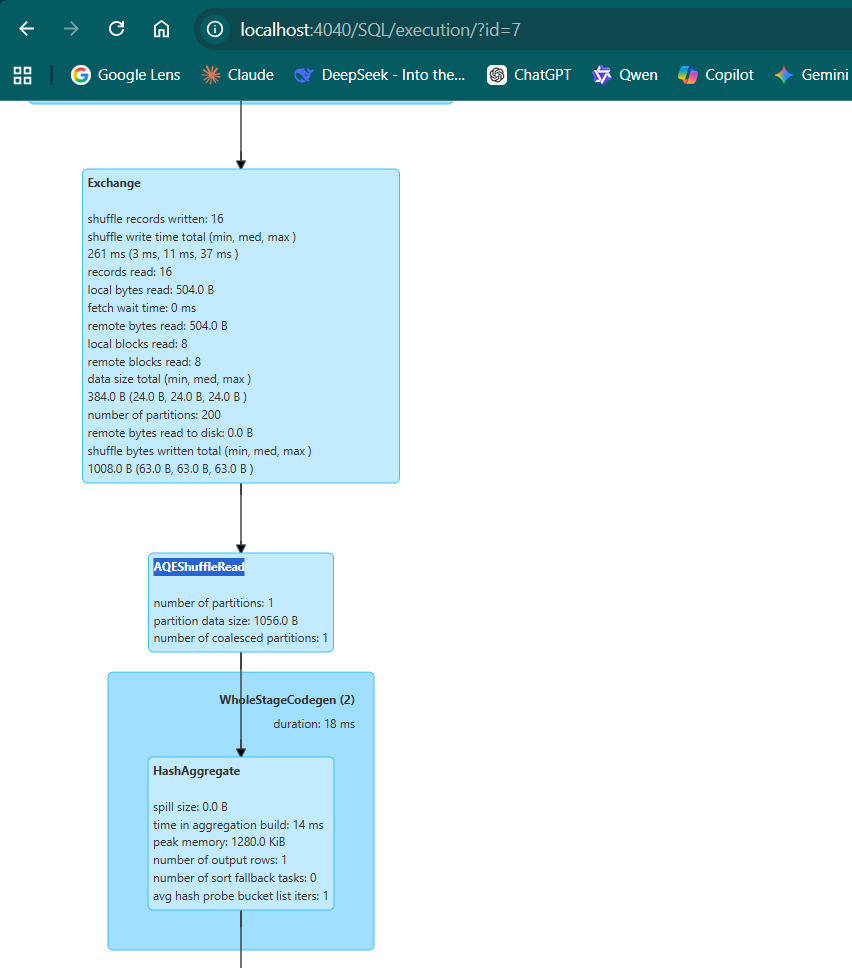

Notice the `AQEShuffleRead` step in the DAG. This means data is being moved across the network.

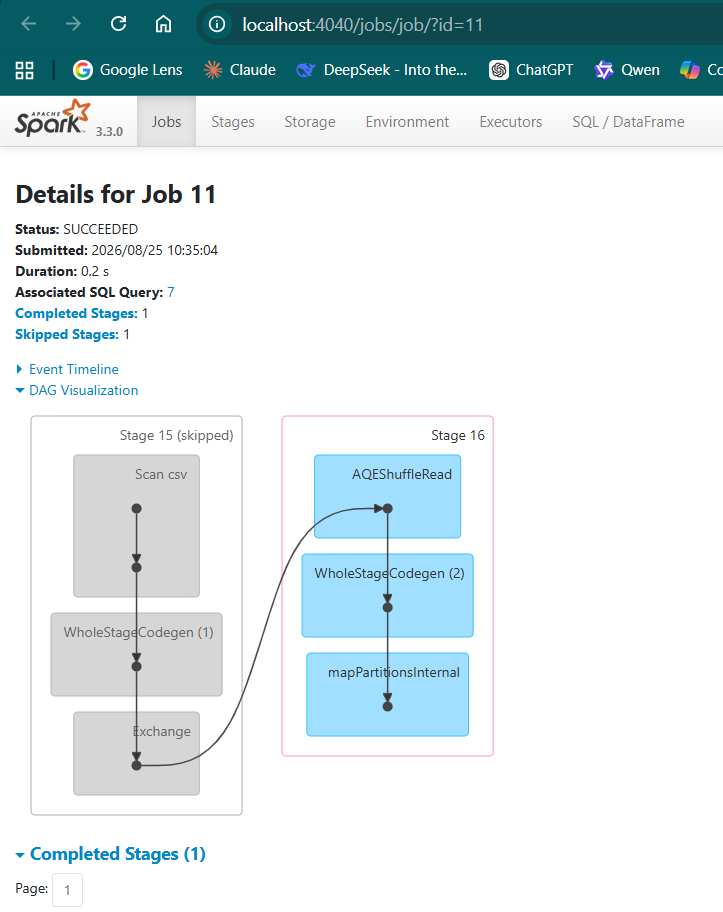

Here you can see the data is read in the first stage, and then all the filtered rows are brought into **1 single task** in the next stage to perform the final count. This data movement across the network is expensive.

In [48]:
# Accumulators
dept_sal = spark.sparkContext.accumulator(0)
# 0 is the default value for the start

In [49]:
# Use foreach
def calculate_salary(department_id, salary):
    if department_id == 6:
        dept_sal.add(salary)

emp.foreach(lambda row : calculate_salary(row.department_id, row.salary))


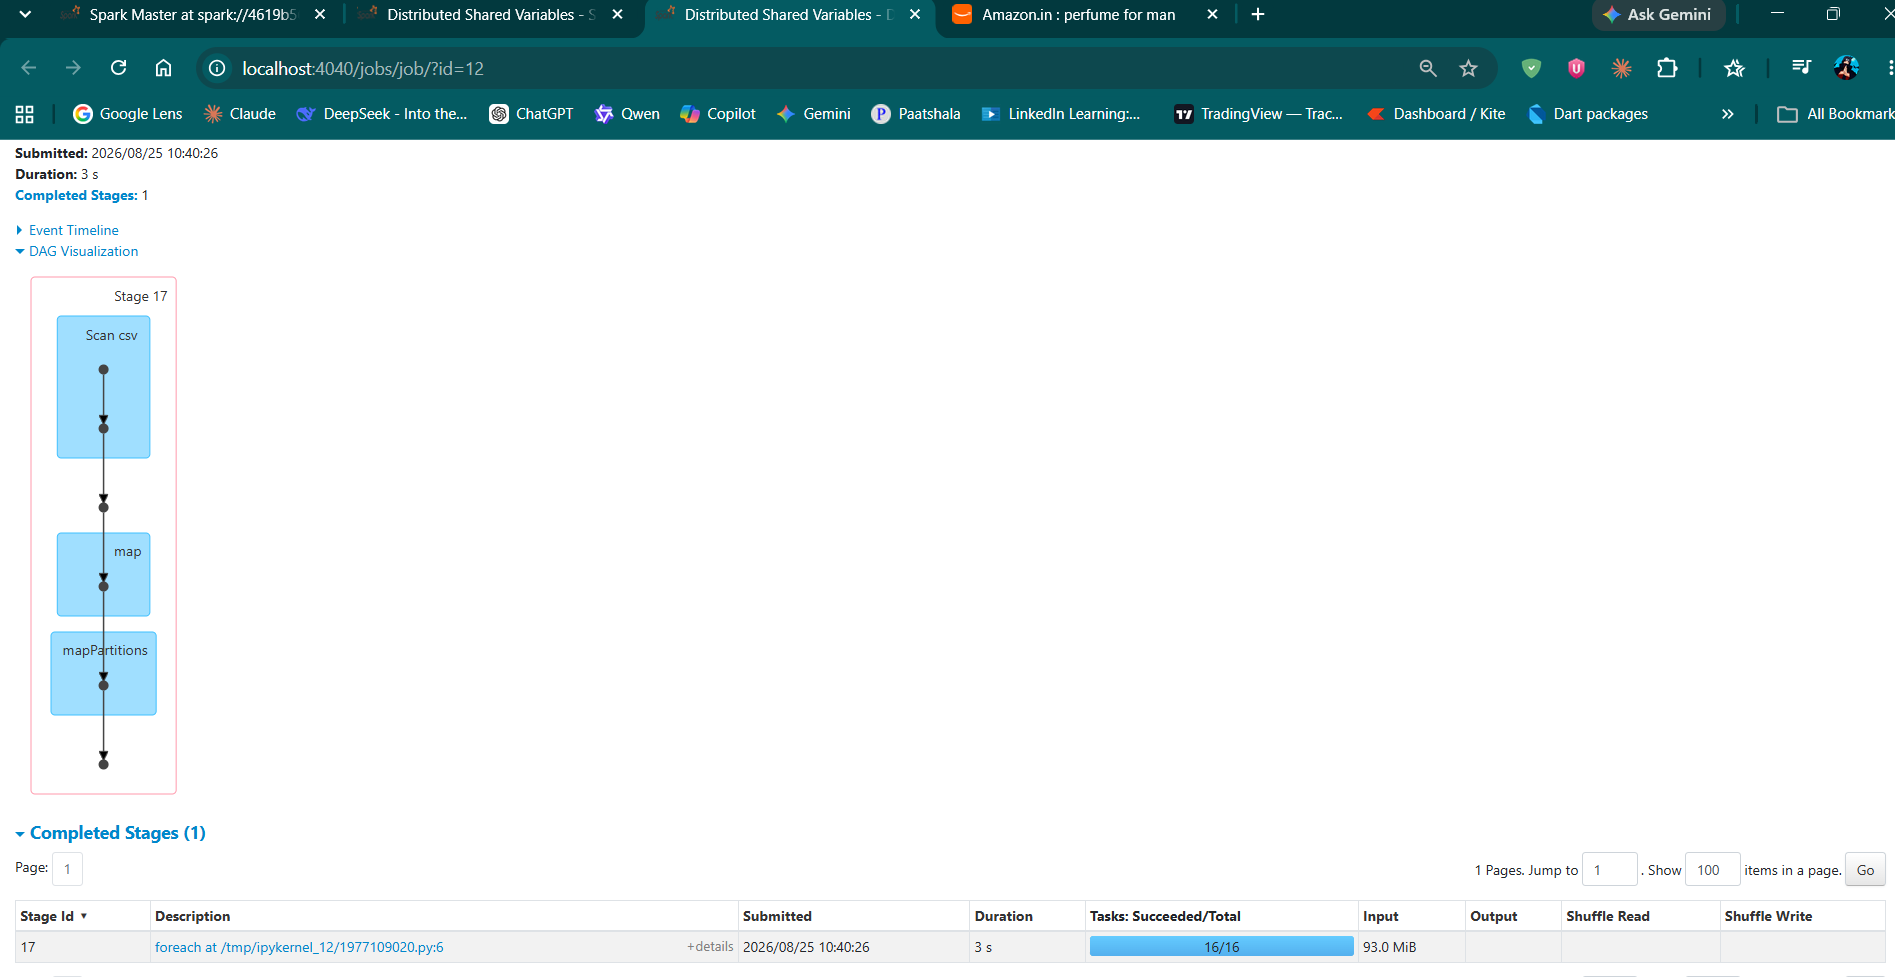

### The Solution: Single Stage Execution

Notice that with the accumulator, **everything happened in a single stage**. 

Because the accumulator is updated row by row locally on each executor, there is **no shuffle required**. Spark doesn't need to physically move rows across the network to group them together; it just silently tallies the numbers and sends the final sub-totals back to the driver.

In [50]:
dept_sal.value

50294510721.0

In [ ]:
spark.stop()